# Company Intelligence Q&A — RAG System

A Retrieval-Augmented Generation pipeline over 13,000+ UK companies extracted from the Companies House API.

**Architecture:**
```
User Query → Embed (sentence-transformers) → Retrieve (ChromaDB) → Generate (Groq Llama 3)
```

**Stack:**
- `sentence-transformers` — query and document embeddings
- `ChromaDB` — vector database for semantic retrieval
- `Groq API (Llama 3)` — LLM for answer generation
- `python-dotenv` — secure API key management

In [1]:
!pip3 install pandas numpy matplotlib chromadb sentence-transformers groq dotenv python-dotenv 


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import chromadb
from sentence_transformers import SentenceTransformer
from groq import Groq
from dotenv import load_dotenv
from collections import Counter
import matplotlib.pyplot as plt
import os
import time

load_dotenv()

df = pd.read_csv('companies_final.csv')
embeddings = np.load('embeddings.npy')
embeddings = embeddings[:len(df)]

print(f"Companies loaded: {len(df):,}")
print(f"Embedding dimensions: {embeddings.shape}")
print(f"Clusters: {df['cluster_label'].nunique()}")
df.head(3)

Companies loaded: 13,177
Embedding dimensions: (13177, 384)
Clusters: 19


,CompanyName,CompanyNumber,CompanyStatus,RegAddress.PostTown,RegAddress.PostCode,RegAddress.Country,SICCode.SicText_1,IncorporationDate,website,verified,x,y,cluster,cluster_label
0,JACKS DIGITAL LTD.,10795651,active,SWANSEA,SA7 9FS,United Kingdom,62012,2017-05-31,https://www.jacks.co.uk,True,8.829205,4.537180,13,Global business services
1,FUNCTION1 LIMITED,07479824,active,CHELTENHAM,GL52 8FU,England,62020,2010-12-30,https://www.function1.com,True,6.303386,2.149475,8,General IT and software
2,UNREAL SOLUTIONS LTD,14451923,active,LONDON,WC2H 9JQ,United Kingdom,62011,2022-10-31,https://unreal.io,True,10.840724,2.047858,8,General IT and software


In [3]:
client = chromadb.Client()

collection = client.create_collection(
    name="company_intelligence",
    metadata={"hnsw:space": "cosine"}
)

documents, metadatas, ids = [], [], []

for idx, row in df.iterrows():
    doc = f"{row['CompanyName']} | {row['SICCode.SicText_1']} | {row.get('cluster_label', 'Unknown')} | {row.get('RegAddress.PostTown', '')}, {row.get('RegAddress.Country', '')}"
    documents.append(doc)
    metadatas.append({
        'company_name': str(row['CompanyName']),
        'sic_code': str(row['SICCode.SicText_1']),
        'cluster': str(row.get('cluster_label', 'Unknown')),
        'location': str(row.get('RegAddress.PostTown', '')),
        'website': str(row.get('website', ''))
    })
    ids.append(str(idx))

batch_size = 1000
for i in range(0, len(documents), batch_size):
    collection.add(
        documents=documents[i:i+batch_size],
        embeddings=embeddings[i:i+batch_size].tolist(),
        metadatas=metadatas[i:i+batch_size],
        ids=ids[i:i+batch_size]
    )

print(f"Indexed {collection.count():,} companies into ChromaDB")

Indexed 13,177 companies into ChromaDB


In [14]:
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
groq_client = Groq(api_key=os.getenv('GROQ_API_KEY'))

def retrieve(query, n_results=5):
    query_embedding = embed_model.encode([query])[0].tolist()
    results = collection.query(
        query_embeddings=[query_embedding],
        n_results=n_results
    )
    return results['documents'][0], results['metadatas'][0], results['distances'][0]

def generate(query, context_docs):
    context = "\n".join([f"- {doc}" for doc in context_docs])
    prompt = f"""You are a UK company intelligence assistant. Use the retrieved companies below to answer the question accurately and concisely.

Retrieved Companies:
{context}

Question: {query}

Answer:"""
    response = groq_client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=400,
        temperature=0.3
    )
    return response.choices[0].message.content

def rag_query(query, n_results=5, verbose=True):
    start = time.time()
    
    if not query.strip():
        return {"error": "Empty query"}
    
    try:
        docs, metas, distances = retrieve(query, n_results)
        answer = generate(query, docs)
        elapsed = round(time.time() - start, 2)
        
        result = {
            "query": query,
            "answer": answer,
            "retrieved": metas,
            "similarity_scores": [round(1 - d, 3) for d in distances],
            "latency_seconds": elapsed
        }
        
        if verbose:
            print(f"Query: {query}")
            print(f"Latency: {elapsed}s | Top similarity: {result['similarity_scores'][0]}")
            print(f"\nAnswer:\n{answer}")
            print("\nRetrieved Companies:")
            for m, s in zip(metas, result['similarity_scores']):
                print(f"  [{s}] {m['company_name']} — {m['cluster']} — {m['location']}")
        
        return result
    
    except Exception as e:
        return {"error": str(e), "query": query}

print("RAG pipeline ready")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RAG pipeline ready


In [15]:
test_queries = [
    "Find software companies based in London",
    "Which companies work in cybersecurity?",
    "Show me fintech or financial services companies",
    "Find AI or machine learning companies",
    "Which companies are in Manchester?"
]

results = []
for q in test_queries:
    print("\n" + "="*60)
    r = rag_query(q)
    results.append(r)

print("\nAll queries completed")


Query: Find software companies based in London
Latency: 0.49s | Top similarity: 0.562

Answer:
Based on the retrieved companies, the software companies based in London are:

1. AMEDYA LTD. (62012, General IT and software)
2. PRODECODE LTD (62012, General IT and software)
3. PARTICULAR PROGRAMS LTD (62012, General IT and software)

Retrieved Companies:
  [0.562] AMEDYA LTD. — General IT and software — LONDON
  [0.555] KINGDOM FIVE ASSOCIATES LTD — General IT and software — ANDOVER
  [0.554] PRODECODE LTD — General IT and software — LONDON
  [0.537] LONDON CODE LTD — Unclustered — ST. ALBANS
  [0.536] PARTICULAR PROGRAMS LTD — General IT and software — LONDON

Query: Which companies work in cybersecurity?
Latency: 0.26s | Top similarity: 0.616

Answer:
Based on the retrieved companies, the following companies work in cybersecurity:

1. CYBERSAFEHAVEN TECHNOLOGIES LIMITED
2. CYBERSECURE365 UK LTD

Both of these companies have the number 62012, which is a SIC code for 'General IT and soft

In [16]:
print(results)

[{'query': 'Find software companies based in London', 'answer': 'Based on the retrieved companies, the software companies based in London are:\n\n1. AMEDYA LTD. (62012, General IT and software)\n2. PRODECODE LTD (62012, General IT and software)\n3. PARTICULAR PROGRAMS LTD (62012, General IT and software)', 'retrieved': [{'location': 'LONDON', 'company_name': 'AMEDYA LTD.', 'cluster': 'General IT and software', 'sic_code': '62012', 'website': 'https://www.amedya.com'}, {'sic_code': '63120', 'company_name': 'KINGDOM FIVE ASSOCIATES LTD', 'cluster': 'General IT and software', 'website': 'https://www.kingdomfiveassociates.co.uk', 'location': 'ANDOVER'}, {'cluster': 'General IT and software', 'sic_code': '62012', 'company_name': 'PRODECODE LTD', 'website': 'https://www.prodecode.co.uk', 'location': 'LONDON'}, {'sic_code': '62011', 'company_name': 'LONDON CODE LTD', 'location': 'ST. ALBANS', 'cluster': 'Unclustered', 'website': 'https://www.londoncode.co.uk'}, {'location': 'LONDON', 'website

In [17]:
print("Retrieval Quality Evaluation")
print("-" * 40)

latencies = [r['latency_seconds'] for r in results if 'latency_seconds' in r]
top_scores = [r['similarity_scores'][0] for r in results if 'similarity_scores' in r]
avg_scores = [sum(r['similarity_scores'])/len(r['similarity_scores']) for r in results if 'similarity_scores' in r]

print(f"Average latency:          {sum(latencies)/len(latencies):.2f}s")
print(f"Average top similarity:   {sum(top_scores)/len(top_scores):.3f}")
print(f"Average mean similarity:  {sum(avg_scores)/len(avg_scores):.3f}")
print(f"Queries with score > 0.5: {sum(1 for s in top_scores if s > 0.5)}/{len(top_scores)}")

Retrieval Quality Evaluation
----------------------------------------
Average latency:          0.31s
Average top similarity:   0.609
Average mean similarity:  0.579
Queries with score > 0.5: 5/5


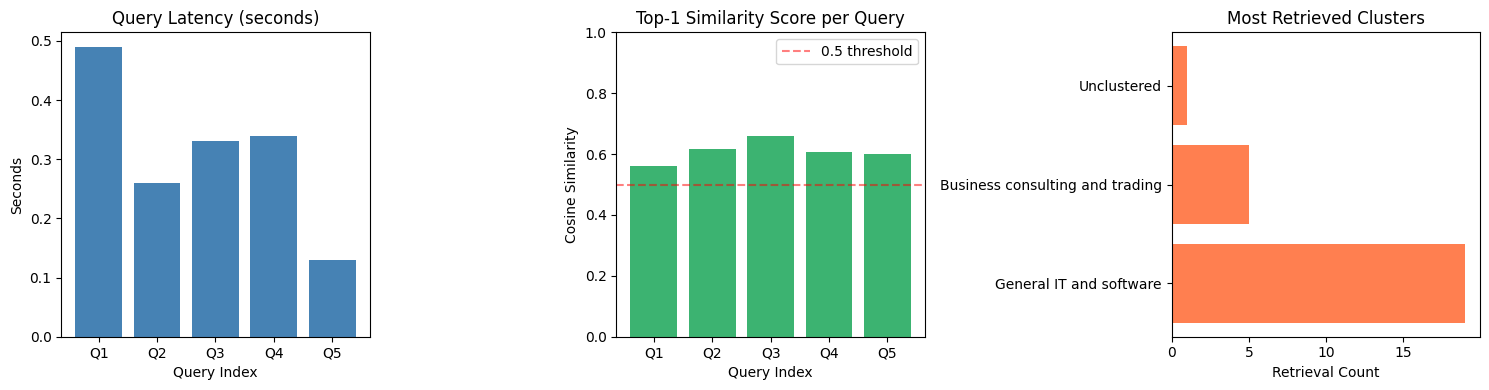

Saved: rag_evaluation.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(range(len(latencies)), latencies, color='steelblue')
axes[0].set_title('Query Latency (seconds)')
axes[0].set_xlabel('Query Index')
axes[0].set_ylabel('Seconds')
axes[0].set_xticks(range(len(test_queries)))
axes[0].set_xticklabels([f'Q{i+1}' for i in range(len(test_queries))])

axes[1].bar(range(len(top_scores)), top_scores, color='mediumseagreen')
axes[1].set_title('Top-1 Similarity Score per Query')
axes[1].set_xlabel('Query Index')
axes[1].set_ylabel('Cosine Similarity')
axes[1].set_ylim(0, 1)
axes[1].set_xticks(range(len(test_queries)))
axes[1].set_xticklabels([f'Q{i+1}' for i in range(len(test_queries))])
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='0.5 threshold')
axes[1].legend()

cluster_hits = []
for r in results:
    if 'retrieved' in r:
        cluster_hits.extend([m['cluster'] for m in r['retrieved']])

cluster_counts = Counter(cluster_hits).most_common(8)
clusters, counts = zip(*cluster_counts)
axes[2].barh(clusters, counts, color='coral')
axes[2].set_title('Most Retrieved Clusters')
axes[2].set_xlabel('Retrieval Count')

plt.tight_layout()
plt.savefig('rag_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: rag_evaluation.png")

In [ ]:
print("Interactive Q&A — type 'quit' to exit\n")

while True:
    query = input("Ask about UK companies: ").strip()
    if query.lower() in ('quit', 'exit', 'q'):
        print("Exiting.")
        break
    if query:
        print()
        rag_query(query)
        print()

Interactive Q&A — type 'quit' to exit

